In [2]:
# Zachary Katz
# zachary_katz@mines.edu
# 20 May 2026

"""
Make plots and geoJSONs of swot High Rate masks kmls


Datasets required (Update paths to match your local system):

Desired kml file from SWOT events page https://podaac.jpl.nasa.gov/SWOT-events/SWOT_events.html
e.g.,   KMLs/swot_science_hr_Apr2025-v10b_perPass.kml
        KMLs/swot_science_hr_Oct2025-v11S_perPass.kml

RINGS Grounding line from https://doi.org/10.21334/NPOLAR.2025.8CEC2D20
e.g,    RINGS_2022/RINGS_coastline_2022.shp
        RINGS_2022/RINGS_grounded_2022.shp
        RINGS_2022/RINGS_iceshelves_2022.shp
        RINGS_2022/RINGS_islands_ADD.shp
        RINGS_2022/RINGS_polygonmask.shp
"""

# Imports and Extensions
import shapefile
import shapely
import pandas as pd

import fiona
import geopandas as gpd

import matplotlib.pyplot as plt
import cartopy.crs as ccrs

from pathlib import Path

# Paths to datasets (download from links above and set paths)
kml_path_Apr2025 = './_Data/swot_science_hr_Apr2025-v10b_perPass.kml'
kml_path_Oct2025 = './Data/swot-paper/swot_science_hr_Oct2025-v11S_perPass.kml'
rings_coastline_path = '/mnt/c/Users/ZacharyKatz/Desktop/Research/Background/RINGS_2022/RINGS_coastline_2022.shp'
rings_grounded_path = '/mnt/c/Users/ZacharyKatz/Desktop/Research/Background/RINGS_2022/RINGS_grounded_2022.shp'
rings_iceshelves_path = '/mnt/c/Users/ZacharyKatz/Desktop/Research/Background/RINGS_2022/RINGS_iceshelves_2022.shp'
rings_islands_ADD = '/mnt/c/Users/ZacharyKatz/Desktop/Research/Background/RINGS_2022/RINGS_islands_ADD.shp'
rings_polygonmask = '/mnt/c/Users/ZacharyKatz/Desktop/Research/Background/RINGS_2022/RINGS_polygonmask.shp'

# Path to save trimmed KMLs
trimmed_kml_path_Apr2025 = './_Data/trimmed_kmls/hr_Apr2025_below60S.kml'
trimmed_kml_path_Oct2025 = './_Data/trimmed_kmls/hr_Oct2025_below60S.kml'


# Helper functions
# Load KML and grab convex hull of each feature
def read_all_kml_layers(path: Path, driver="KML") -> gpd.GeoDataFrame:
    """Load all non-empty KML/KMZ layers into a single GeoDataFrame."""
    layers = fiona.listlayers(str(path))
    frames = []
    for lyr in layers:
        try:
            gdf = gpd.read_file(path, driver=driver, layer=lyr)
            if not gdf.empty:
                frames.append(gdf)
        except Exception as exc:
            print(f"Skipped layer '{lyr}': {exc}")
    if not frames:
        raise RuntimeError(f"No valid layers in {path}")
    return gpd.GeoDataFrame(pd.concat(frames, ignore_index=True))

def save_kml(gdf: gpd.GeoDataFrame, out_path: Path) -> None:
    """Save a GeoDataFrame as KML (for future reuse)."""
    out_path.parent.mkdir(parents=True, exist_ok=True)
    gdf.to_file(out_path, driver="KML")


def plot_RINGS_shapefile(
    records_list: list[shapefile._Record],
    shapes_list: list[shapefile.Shape],
    field_names_list: list[str],
    ax ,
    colors: list[str],
    transform,
    fill: bool = False,
    zorder: int = 2,
    linewidth: int = 2,
    ) -> None:
    """
    Plots the given records and shapes on axis ax.

    Example usage:
    
    plot_RINGS_shapefile(records_list=records_full, shapes_list=shapes_full, field_names_list=field_names_full, ax=inset, colors=['lightgray','white'],
        transform=ps71_projection, fill=True, zorder=2, linewidth=1)

    plot_RINGS_shapefile(records_list=records_full, shapes_list=shapes_full, field_names_list=field_names_full, ax=ax, colors=['white','None'],
        transform=ps71_projection, fill=False, zorder=2, linewidth=1)

    Parameters
    ----------
    records : list[shapefile._Record]
        Shapely record containing shape classification
    shapes : list[shapefile.Shape]
        Shapely shape points
    ax : cartopy.mpl.geoaxes.GeoAxes
        Axes to polot on
    colors : list[str]
       [Grounded ice color, Ice Shelf color]; Must be length 2
    """
    for records, shapes, field_names in zip(records_list, shapes_list, field_names_list):
        for record, shape in zip(records, shapes):
            rec_dict = dict(zip(field_names, record))
            classification = rec_dict["Type"]
            points = shape.points
            parts = list(shape.parts)
            parts.append(len(points)) # Append the end index of the last part of the shapefile
            for i in range(len(parts) - 1):
                    part = points[parts[i] : parts[i + 1]]
                    if classification == "Coastline":
                        if fill:
                            ax.fill(*zip(*part), color=colors[1], zorder=zorder,transform=transform)
                        else:
                            ax.plot(*zip(*part), color=colors[1], linewidth=linewidth, zorder=zorder,transform=transform)
                    elif classification == "Grounded":
                        if fill:
                            ax.fill(*zip(*part), color=colors[0], zorder=zorder,transform=transform)
                        else:
                            ax.plot(*zip(*part), color=colors[0], linewidth=linewidth, zorder=zorder,transform=transform)
                    elif classification == "Transient":
                        if fill:
                            ax.fill(*zip(*part), color=colors[0], zorder=zorder,transform=transform)
                        else:
                            ax.plot(*zip(*part), color=colors[0], linewidth=linewidth, zorder=zorder,transform=transform)
                    elif classification == "Island":
                        if fill:
                            ax.fill(*zip(*part), color=colors[0], zorder=zorder,transform=transform)
                        else:
                            ax.plot(*zip(*part), color=colors[0], linewidth=linewidth, zorder=zorder,transform=transform)
                    else:
                        continue

In [3]:
# Load grounding lines
paths = [
    rings_coastline_path,
    rings_grounded_path,
    rings_iceshelves_path,
    rings_islands_ADD,
    rings_polygonmask,
]

records_full = []
shapes_full = []
field_names_full = []

for path in paths:
    sf = shapefile.Reader(path)
    records_full.append(sf.records())
    shapes_full.append(sf.shapes())
    field_names_full.append([f[0] for f in sf.fields[1:]])

ice_shelf_polygons = []
grounded_polygons = []

sf = shapefile.Reader(rings_iceshelves_path)
fields = sf.fields[1:]  # Skip deletion flag
field_names = [field[0] for field in fields]

records = sf.records()
shapes = sf.shapes()

for record, shape in zip(records, shapes):
    rec_dict = dict(zip(field_names, record))
    classification = rec_dict["Type"]
    points = shape.points
    parts = list(shape.parts)
    parts.append(len(points))  # Append the end index of the last part
    for i in range(len(parts) - 1):
        part = points[parts[i] : parts[i + 1]]
        polygon = shapely.Polygon(part)
        if (
            classification == "Isolated island"
            or classification == "Ice rise or connected island"
            or classification == "Grounded ice or land"
        ):
            if polygon.is_valid:
                grounded_polygons.append(polygon)
        elif classification == "Ice shelf":
            if polygon.is_valid:
                ice_shelf_polygons.append(polygon)
        else:
            print(f"Unknown classification: {classification}")

In [5]:
# KMLs are large because they have all HR SWOT data availability. Trim to south
# of -60 degrees south and save trimmed kml. Only runs if necessary; this takes
# ~30 minutes per kml. 

trimmed_paths = [trimmed_kml_path_Apr2025, trimmed_kml_path_Oct2025]
if not all(Path(path).exists() for path in trimmed_paths):

    kml_Apr2025_full = read_all_kml_layers(kml_path_Apr2025)
    kml_Oct2025_full = read_all_kml_layers(kml_path_Oct2025)
    full_kmls = [kml_Apr2025_full, kml_Oct2025_full]


    for kml, path in zip(full_kmls, trimmed_paths):
        kml_60s = kml.assign(miny=kml.geometry.bounds.miny)
        kml_60s = kml_60s[kml_60s["miny"] < -60].drop(columns=["miny"])
        # Also remove nadir coverage
        if "Name" in kml_60s.columns:
            kml_60s = kml_60s[~kml_60s["Name"].str.contains("Nadir", na=False)]
            save_kml(kml_60s, path)

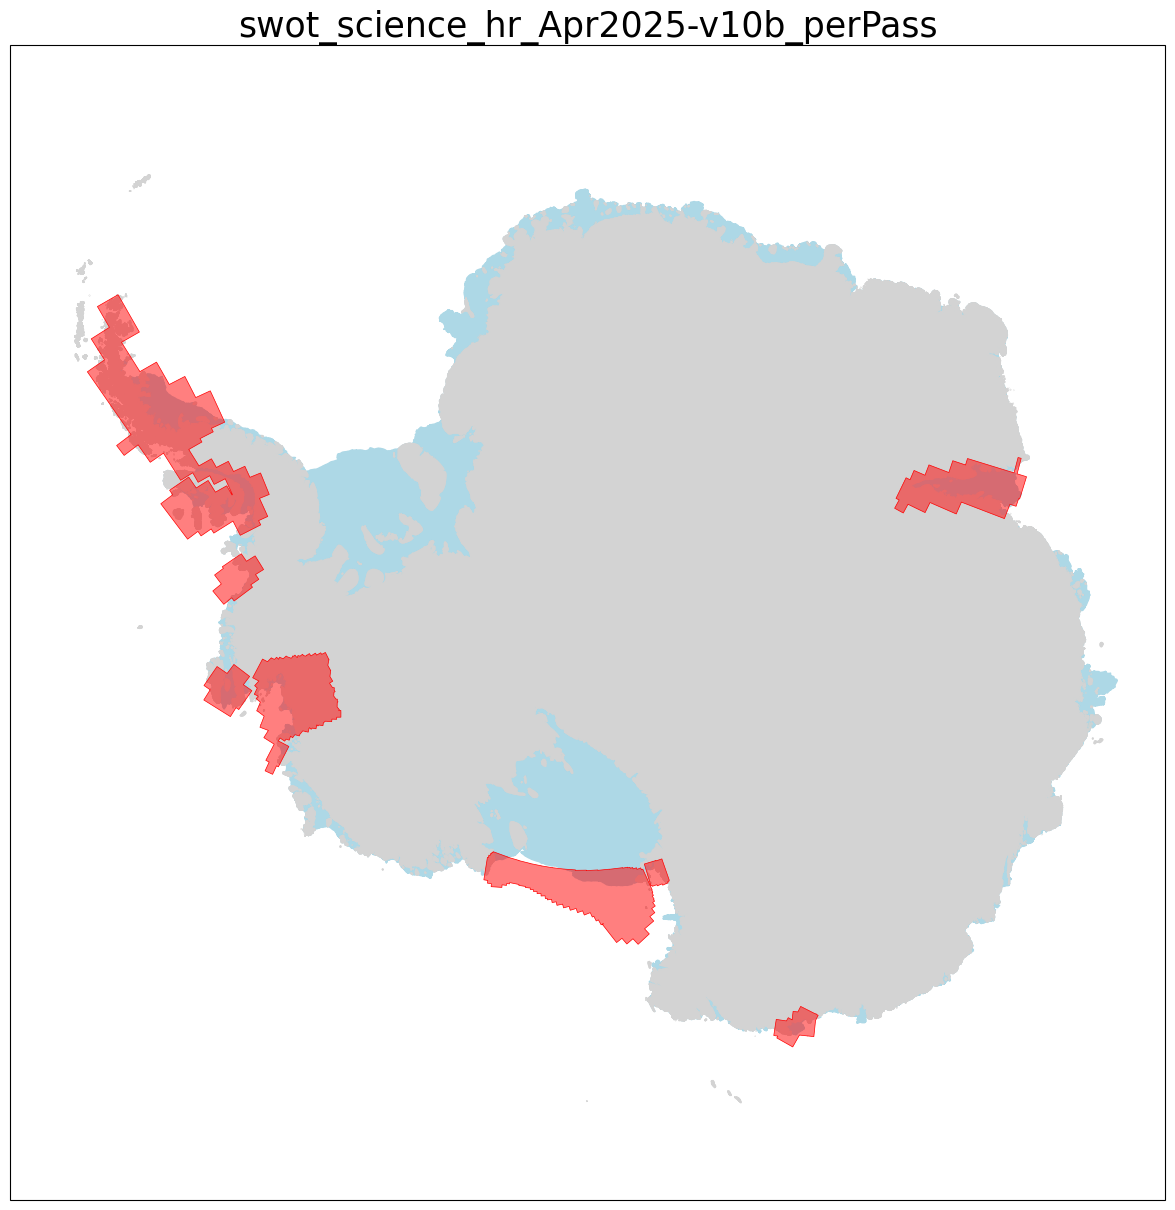

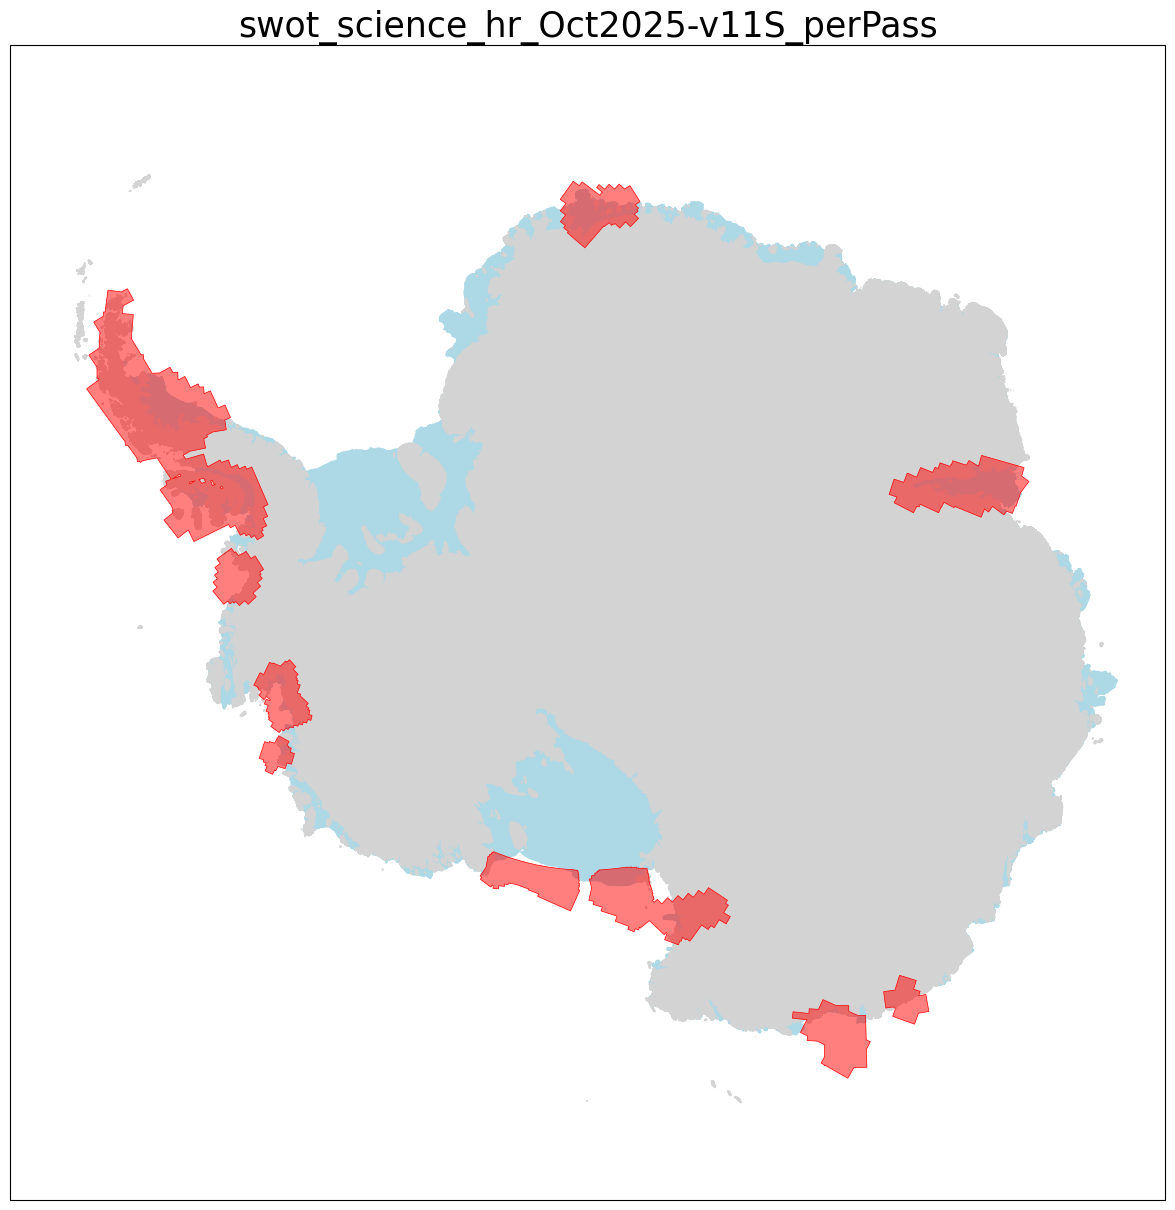

In [7]:
# Merge overlapping swath polygons and plot
ps71_projection = ccrs.Stereographic(central_latitude=-90, central_longitude=0, true_scale_latitude=-71)

kml_Apr2025_trimmed = read_all_kml_layers(trimmed_kml_path_Apr2025)
kml_Oct2025_trimmed = read_all_kml_layers(trimmed_kml_path_Oct2025)
trimmed_kmls = [kml_Apr2025_trimmed, kml_Oct2025_trimmed]
orig_paths = [kml_path_Apr2025, kml_path_Oct2025]

for kml, path in zip(trimmed_kmls, orig_paths):
    # Change to Antarctic polar stereographic
    kml = kml.set_crs("EPSG:4326", allow_override=True)
    kml_3031 = kml.to_crs("EPSG:3031")

    # Take convex hull and find overlaps as new gdf
    kml_3031["geometry"] = kml_3031.convex_hull
    groups = []
    remaining = list(kml_3031.geometry)
    while remaining:
        current = remaining.pop(0)

        changed = True
        while changed:
            changed = False
            overlaps = []

            for geom in remaining:
                if current.intersects(geom):
                    current = current.union(geom)
                    overlaps.append(geom)
                    changed = True

            for geom in overlaps:
                remaining.remove(geom)

        groups.append(current)

    merged_kml = gpd.GeoDataFrame(
        geometry=groups,
        crs=kml_3031.crs,
    )

    # Plot merged kml and grounding lines
    fig, ax = plt.subplots(subplot_kw={'projection': ps71_projection}, figsize=(15, 15))

    plot_RINGS_shapefile(records_list=records_full, shapes_list=shapes_full, field_names_list=field_names_full,
        ax=ax, colors=['lightgray','lightblue'], transform=ps71_projection, fill=True, zorder=0, linewidth=1)

    merged_kml.plot(ax=ax, facecolor=(1, 0, 0, 0.5), edgecolor="red", linewidth=0.5, zorder=1)

    ax.set_xlim(-3000000, 3000000)
    ax.set_ylim(-3000000, 3000000)
    title = f"{path.split('/')[-1].strip('.kml')}"
    ax.set_title(title,fontsize=25)
    ax.set_aspect("equal", adjustable="box")
    fig.savefig(f"./Output/{title}.png", dpi=300, bbox_inches="tight")

    # Save merged kml as geoJSON
    merged_kml.to_file(f"./Output/{title}.geojson",driver="GeoJSON")